# Exploratory Data Analysis (EDA) - New Housing Dataset

(https://www.kaggle.com/datasets/muhammadbinimran/housing-price-prediction-data)

## Khởi tạo và Import các thư viện cần thiết

In [10]:
import kagglehub
import shutil
import os

# Download latest version
path = kagglehub.dataset_download("ghost5/messy-house-price-sample-datasets")

print("Path to dataset files:", path)

target_path = "../data/raw"

# 3. Copy toàn bộ dữ liệu sang thư mục mới
if os.path.exists(target_path):
    shutil.rmtree(target_path) # Xóa nếu thư mục đã tồn tại để tránh lỗi
shutil.copytree(path, target_path)

print("Dữ liệu đã được lưu tại:", os.path.abspath(target_path))

Path to dataset files: C:\Users\Win 11\.cache\kagglehub\datasets\ghost5\messy-house-price-sample-datasets\versions\1
Dữ liệu đã được lưu tại: c:\Users\Win 11\Documents\AI\proj AI ML\data\raw


## Bước 1. Tổng Quan Dữ Liệu & Kiểu Dữ Liệu (Data Overview & Data Types)

Xác định kích thước dữ liệu, định dạng/kiểu dữ liệu và xem trước các dòng dữ liệu mẫu.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('../data/raw/messy_housing_data.csv')
print(f"Kích thước dữ liệu: {data.shape[0]} dòng, {data.shape[1]} cột\n")
print("Kiểu dữ liệu của từng cột:")
data.info()
data.head()

Kích thước dữ liệu: 420 dòng, 6 cột

Kiểu dữ liệu của từng cột:
<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area_sqft   420 non-null    int64  
 1   bedrooms    399 non-null    float64
 2   bathrooms   420 non-null    int64  
 3   year_built  384 non-null    float64
 4   price       370 non-null    str    
 5   location    420 non-null    str    
dtypes: float64(2), int64(2), str(2)
memory usage: 26.3 KB


,area_sqft,bedrooms,bathrooms,year_built,price,location
0,2696,4.0,1,1962.0,2068779.98,austin
1,2017,6.0,4,2008.0,1539208.46,San Francisco
2,1592,3.0,3,1991.0,557909.7,San Francisco
3,3358,2.0,4,1914.0,NaN,chicago
4,1624,2.0,5,1935.0,716945.96,New York City


## Bước 2. Thống Kê Tổng Hợp (Summary Statistics)

Tính toán các chỉ số thống kê cơ bản cho các cột số (numerical) và các biến phân loại (categorical).

In [12]:
# Đối với thuộc tính số
print("Thống kê tổng hợp biến số:")
display(data.describe())

Thống kê tổng hợp biến số:


,area_sqft,bedrooms,bathrooms,year_built
count,420.000000,399.000000,420.00000,384.000000
mean,2621.888095,3.593985,3.02381,1960.197917
std,1330.825892,2.386218,1.45067,37.715887
min,-100.000000,1.000000,1.00000,1900.000000
25%,1462.500000,2.000000,2.00000,1926.000000
50%,2602.000000,3.000000,3.00000,1959.000000
75%,3709.000000,5.000000,4.00000,1994.000000
max,4999.000000,20.000000,5.00000,2026.000000


In [13]:
# Đối với thuộc tính phân loại
print("\nThống kê tổng hợp biến phân loại:")
display(data.describe(include=['O']))


Thống kê tổng hợp biến phân loại:


C:\Users\Win 11\AppData\Local\Temp\ipykernel_15720\2660752980.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(data.describe(include=['O']))


,price,location
count,370,420
unique,345,43
top,unavailable,san francisco
freq,7,29


## Bước 3. Phân Tích Đơn Biến & Phân Phối (Univariate Analysis & Distributions)

Vẽ biểu đồ phân phối cho cột location thô trước khi thực hiện chuẩn hóa dữ liệu.

Các giá trị duy nhất thô trong cột 'location' (43 nhóm):
['austin', 'San Francisco', 'chicago', 'New York City', 'Chicago', 'miami', 'san francisco', 'LA', 'l.a.', 'AUSTIN ', 'Austin', 'Los Angeles ', 'La ', 'Chicago ', 'SF', 'boston', 'Chicgo', 'nyc', 'Boston', 'Los Angeles', 'los angeles', 'NYC', 'New York city', 'NEW YORK CITY', 'LOS ANGELES ', 'Austin ', 'sf', 'San Francisco ', 'L.A.', 'Miami', 'Bostan', 'Boston ', 'Miami ', 'SAN FRANCISCO', 'L.A. ', 'Sf ', 'New York City ', 'BOSTON', 'CHICAGO ', 'Nyc ', 'CHICAGO', 'AUSTIN', 'MIAMI']
Tổng số giá trị duy nhất thô: 43



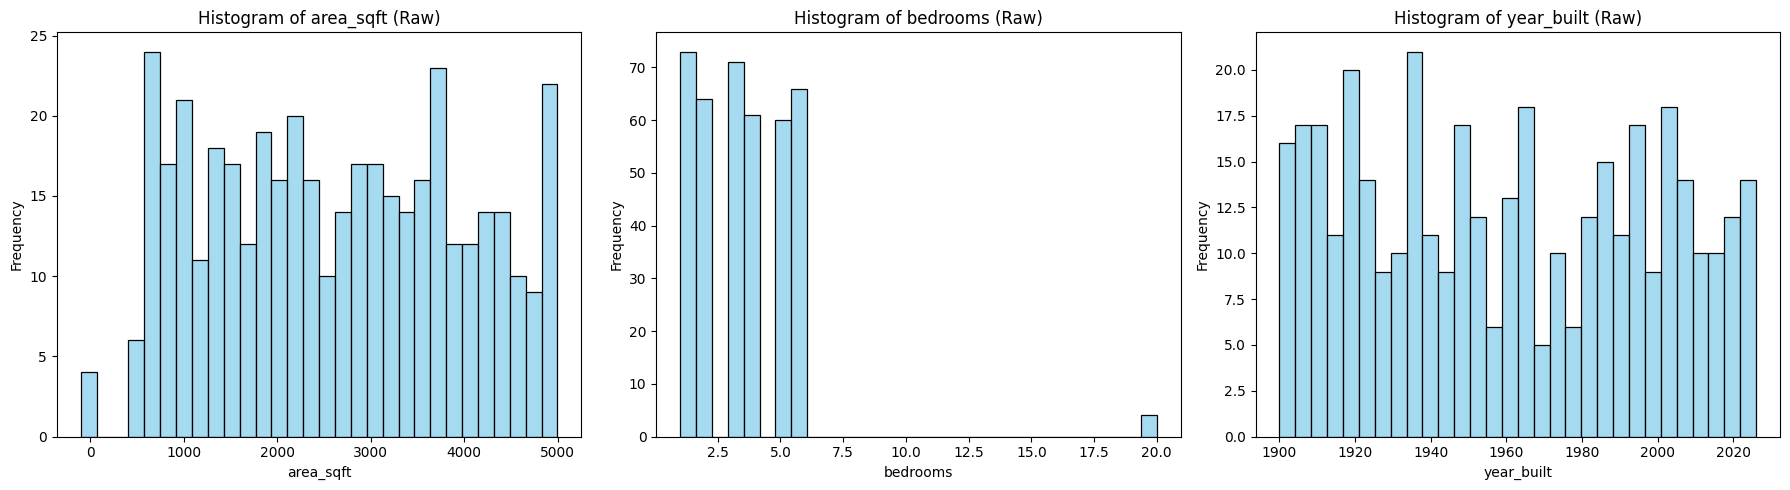

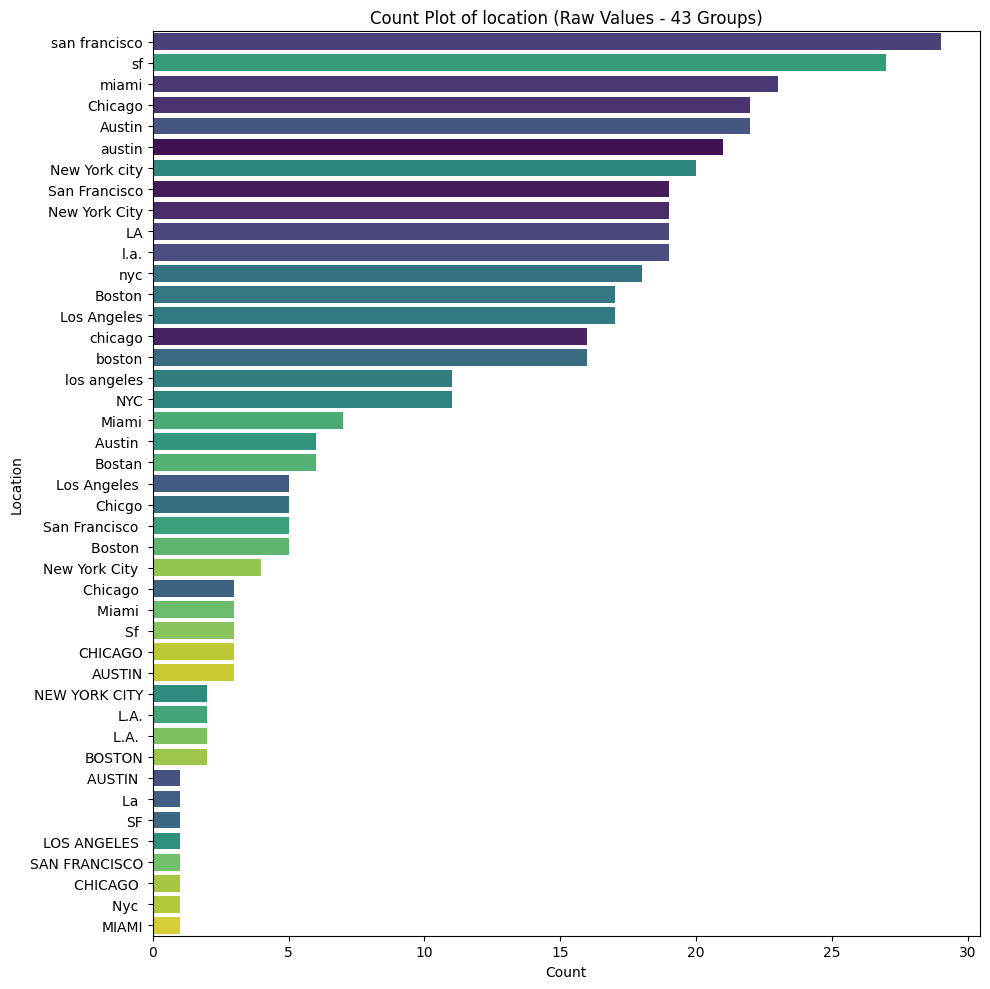

In [14]:
# 1. In ra toàn bộ giá trị unique thô của location
print("Các giá trị duy nhất thô trong cột 'location' (43 nhóm):")
print(data['location'].unique().tolist())
print(f"Tổng số giá trị duy nhất thô: {data['location'].nunique()}\n")

# 2. Vẽ 3 biểu đồ histogram cho các biến số thô đã là numeric (area_sqft, bedrooms, year_built)
plot_cols_raw = ['area_sqft', 'bedrooms', 'year_built']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(plot_cols_raw):
    sns.histplot(data[col].dropna(), bins=30, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Histogram of {col} (Raw)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# 3. Vẽ biểu đồ đếm nằm ngang (horizontal countplot) cho location thô để hiển thị rõ tên
plt.figure(figsize=(10, 10))
sns.countplot(y='location', hue='location', data=data, order=data['location'].value_counts().index, palette='viridis', legend=False)
plt.title('Count Plot of location (Raw Values - 43 Groups)')
plt.xlabel('Count')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

Các giá trị duy nhất trong cột 'location' sau khi chuẩn hóa (7 nhóm):
['austin', 'san francisco', 'chicago', 'new york city', 'miami', 'los angeles', 'boston']
Tổng số giá trị duy nhất sau chuẩn hóa: 7



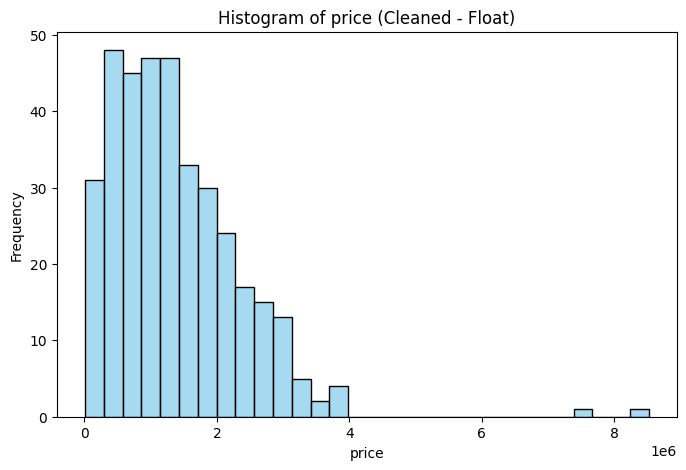

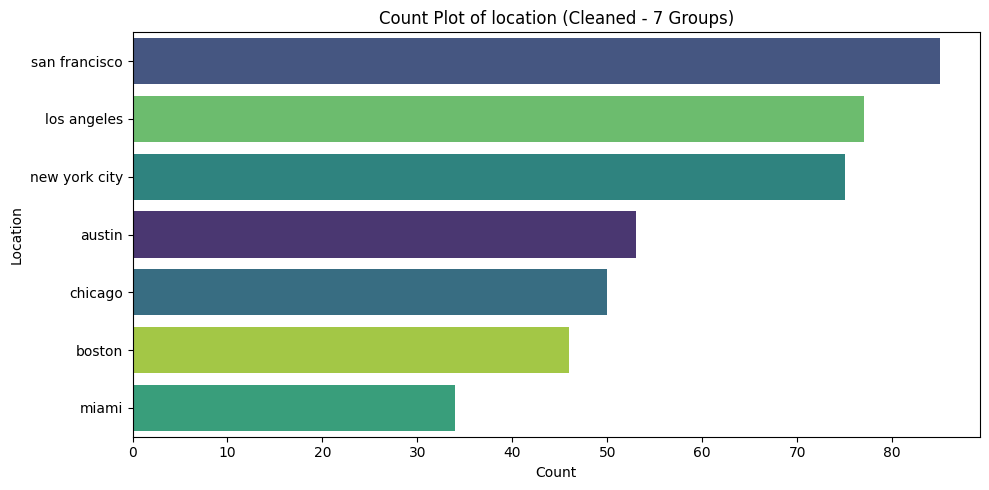

In [15]:
# 1. Lưu lại cột price thô để kiểm tra và thống kê ở các bước sau
data['price_raw'] = data['price']

# 2. Chuyển đổi cột price thành kiểu float (ép kiểu các giá trị không hợp lệ như 'unavailable' về NaN)
data['price'] = pd.to_numeric(data['price'], errors='coerce')

# 3. Chuẩn hóa tên location thành dạng chữ thường (lowercase) chuẩn, gộp các thành phố trùng lặp
def clean_location(loc):
    if not isinstance(loc, str):
        return np.nan
    loc = loc.strip().lower()
    if loc in ['la', 'l.a.', 'los angeles']:
        return 'los angeles'
    if loc in ['sf', 'san francisco']:
        return 'san francisco'
    if loc in ['nyc', 'new york city']:
        return 'new york city'
    if loc in ['chicago', 'chicgo']:
        return 'chicago'
    if loc in ['boston', 'bostan']:
        return 'boston'
    return loc

data['location'] = data['location'].apply(clean_location)

# In ra các giá trị unique sau khi chuẩn hóa
print("Các giá trị duy nhất trong cột 'location' sau khi chuẩn hóa (7 nhóm):")
print(data['location'].unique().tolist())
print(f"Tổng số giá trị duy nhất sau chuẩn hóa: {data['location'].nunique()}\n")

# 4. Vẽ biểu đồ histogram cho biến price sau khi đã được chuyển đổi thành float thành công
plt.figure(figsize=(8, 5))
sns.histplot(data['price'].dropna(), bins=30, color='skyblue')
plt.title('Histogram of price (Cleaned - Float)')
plt.xlabel('price')
plt.ylabel('Frequency')
plt.show()

# 5. Vẽ biểu đồ đếm nằm ngang (horizontal countplot) cho location đã được chuẩn hóa
plt.figure(figsize=(10, 5))
sns.countplot(y='location', hue='location', data=data, order=data['location'].value_counts().index, palette='viridis', legend=False)
plt.title('Count Plot of location (Cleaned - 7 Groups)')
plt.xlabel('Count')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

## Bước 4. Phân Tích Song Biến & Tương Quan (Bivariate Analysis, Correlation & Patterns)

Khảo sát mối quan hệ giữa các cặp biến số-số, số-phân loại, và phân loại-phân loại.

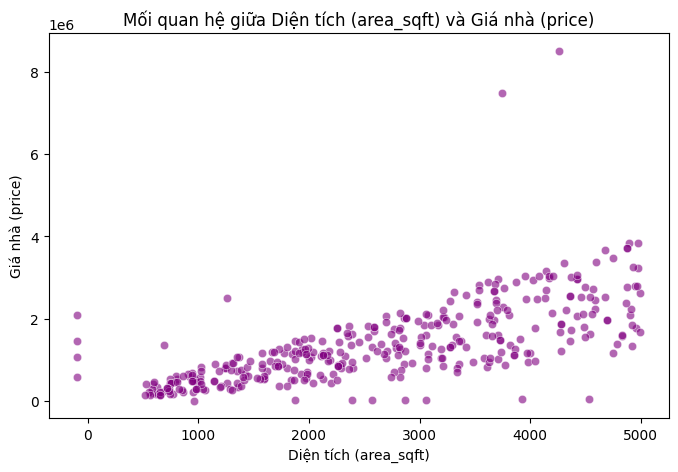

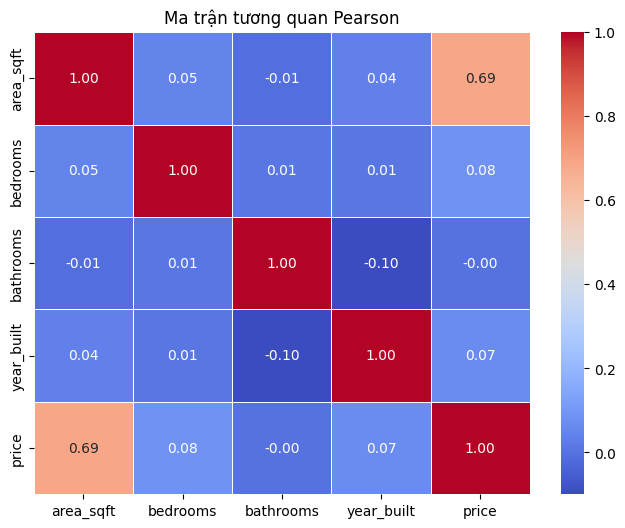

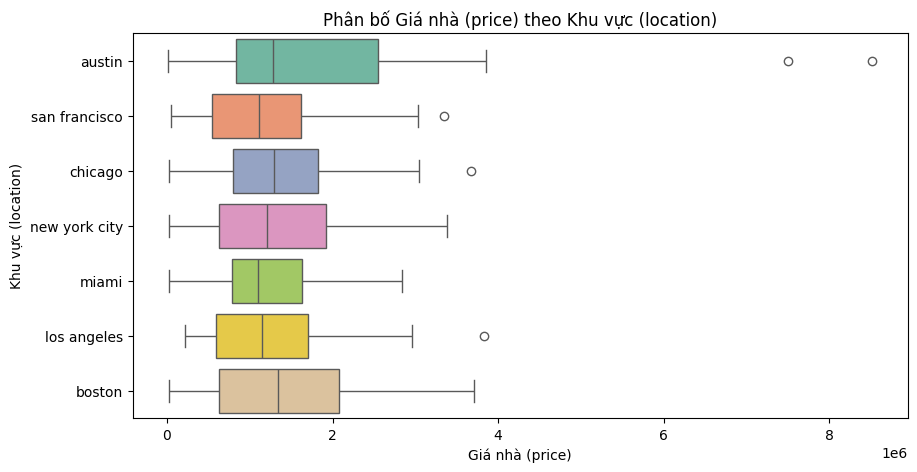

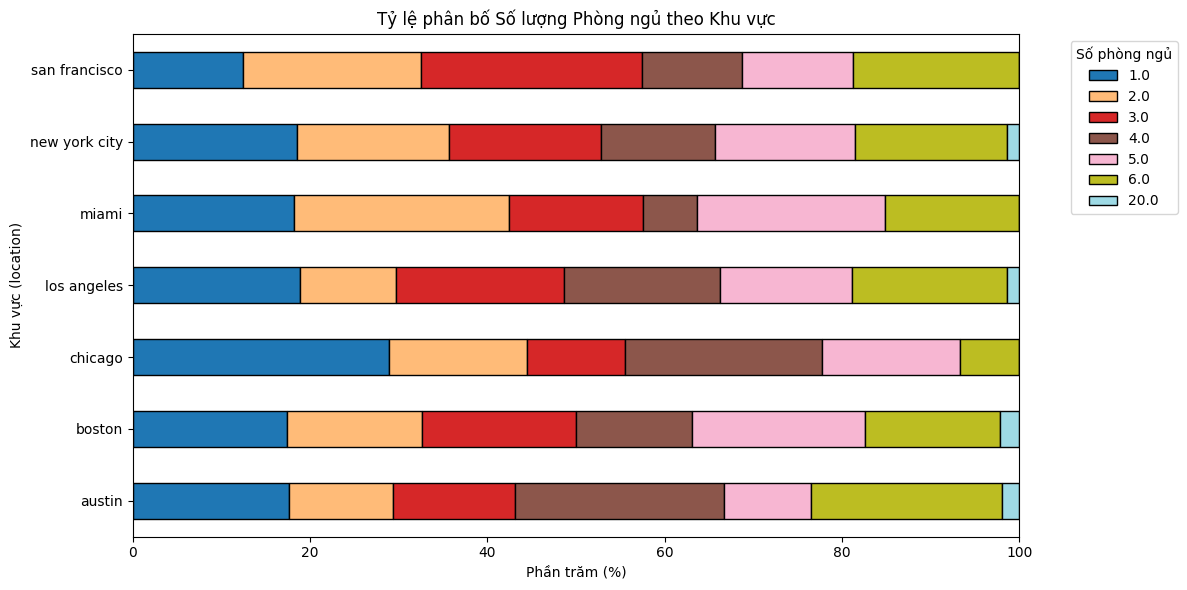

In [16]:
# Mối quan hệ Số - Số: area_sqft vs price
plt.figure(figsize=(8, 5))
sns.scatterplot(x='area_sqft', y='price', data=data, alpha=0.6, color='purple')
plt.title('Mối quan hệ giữa Diện tích (area_sqft) và Giá nhà (price)')
plt.xlabel('Diện tích (area_sqft)')
plt.ylabel('Giá nhà (price)')
plt.show()

# Ma trận tương quan giữa các cột số
plt.figure(figsize=(8, 6))
num_df = data.select_dtypes(include=[np.number])
corr_matrix = num_df.corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan Pearson')
plt.show()

# Mối quan hệ Số - Phân loại: price vs location (vẽ nằm ngang)
plt.figure(figsize=(10, 5))
sns.boxplot(x='price', y='location', hue='location', data=data, palette='Set2', legend=False)
plt.title('Phân bố Giá nhà (price) theo Khu vực (location)')
plt.xlabel('Giá nhà (price)')
plt.ylabel('Khu vực (location)')
plt.show()

# Mối quan hệ Phân loại - Phân loại: location vs bedrooms (vẽ nằm ngang)
cross_tab = pd.crosstab(data['location'], data['bedrooms'], normalize='index') * 100
cross_tab.plot(kind='barh', stacked=True, colormap='tab20', edgecolor='black', figsize=(12, 6))
plt.title('Tỷ lệ phân bố Số lượng Phòng ngủ theo Khu vực')
plt.xlabel('Phần trăm (%)')
plt.ylabel('Khu vực (location)')
plt.legend(title='Số phòng ngủ', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## Bước 5. Nhận Diện Dữ Liệu Thiếu, Trùng Lặp & Ngoại Lệ (Missing Data, Duplicate Data & Outliers)

Rà soát lỗi chất lượng dữ liệu bao gồm dữ liệu thiếu, trùng lặp và các điểm dị biệt (outliers) bằng IQR.

In [17]:
# 1. Kiểm tra dữ liệu thiếu (bao gồm cả NaN và unavailable cho price)
missing_count = data.isnull().sum()
missing_pct = (missing_count / len(data)) * 100

price_raw_nan = data['price_raw'].isnull().sum()
price_raw_unavailable = (data['price_raw'] == 'unavailable').sum()
price_total_missing = data['price'].isnull().sum()

df_missing = pd.DataFrame({
    'Số lượng khuyết (NaN)': missing_count,
    'Tỷ lệ khuyết (%)': missing_pct
})
print("Bảng thống kê dữ liệu khuyết (NaN) sau khi chuẩn hóa:")
display(df_missing)

print("Chi tiết dữ liệu khuyết thiếu cho cột 'price':")
print(f"- Số lượng khuyết gốc (NaN ban đầu): {price_raw_nan} ({ (price_raw_nan/len(data))*100 :.2f}%)")
print(f"- Số lượng giá trị không khả dụng ('unavailable'): {price_raw_unavailable} ({ (price_raw_unavailable/len(data))*100 :.2f}%)")
print(f"- Tổng số lượng khuyết thiếu (NaN + unavailable): {price_total_missing} ({ (price_total_missing/len(data))*100 :.2f}%)\n")

# 2. Kiểm tra dữ liệu trùng lặp
dup_count = data.duplicated().sum()
print(f"Số lượng hàng bị trùng lặp hoàn toàn: {dup_count}\n")

# 3. Phát hiện ngoại lệ bằng phương pháp IQR (1.5 * IQR) cho tất cả 5 cột số
continuous_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'price']
print("Ngoại lệ phát hiện bằng phương pháp IQR (Tứ phân vị):")
iqr_outliers_summary = []
for col in continuous_cols:
    col_data = data[col].dropna()
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
    iqr_outliers_summary.append({
        'Thuộc tính': col,
        'Biên dưới': lower_bound,
        'Biên trên': upper_bound,
        'Số lượng ngoại lệ': len(outliers),
        'Tỷ lệ ngoại lệ (%)': (len(outliers) / len(data)) * 100
    })
display(pd.DataFrame(iqr_outliers_summary))

Bảng thống kê dữ liệu khuyết (NaN) sau khi chuẩn hóa:


,Số lượng khuyết (NaN),Tỷ lệ khuyết (%)
area_sqft,0,0.000000
bedrooms,21,5.000000
bathrooms,0,0.000000
year_built,36,8.571429
price,57,13.571429
location,0,0.000000
price_raw,50,11.904762


Chi tiết dữ liệu khuyết thiếu cho cột 'price':
- Số lượng khuyết gốc (NaN ban đầu): 50 (11.90%)
- Số lượng giá trị không khả dụng ('unavailable'): 7 (1.67%)
- Tổng số lượng khuyết thiếu (NaN + unavailable): 57 (13.57%)

Số lượng hàng bị trùng lặp hoàn toàn: 20

Ngoại lệ phát hiện bằng phương pháp IQR (Tứ phân vị):


,Thuộc tính,Biên dưới,Biên trên,Số lượng ngoại lệ,Tỷ lệ ngoại lệ (%)
0,area_sqft,-1.907250e+03,7.078750e+03,0,0.000000
1,bedrooms,-2.500000e+00,9.500000e+00,4,0.952381
2,bathrooms,-1.000000e+00,7.000000e+00,0,0.000000
3,year_built,1.824000e+03,2.096000e+03,0,0.000000
4,price,-1.191027e+06,3.731998e+06,4,0.952381


## Bước 6. Đánh Giá Chất Lượng Dữ Liệu & Trực Quan Hóa (Data Quality & Data Visualization)

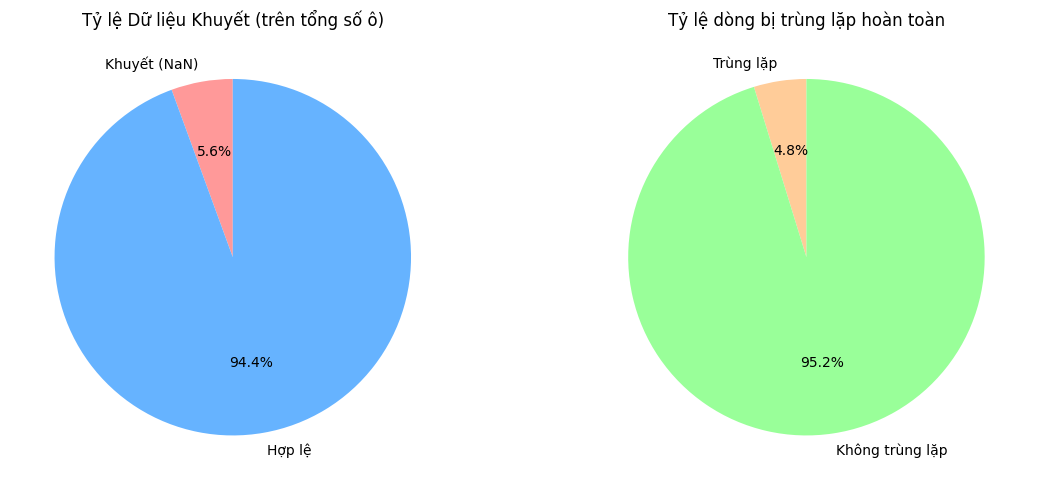

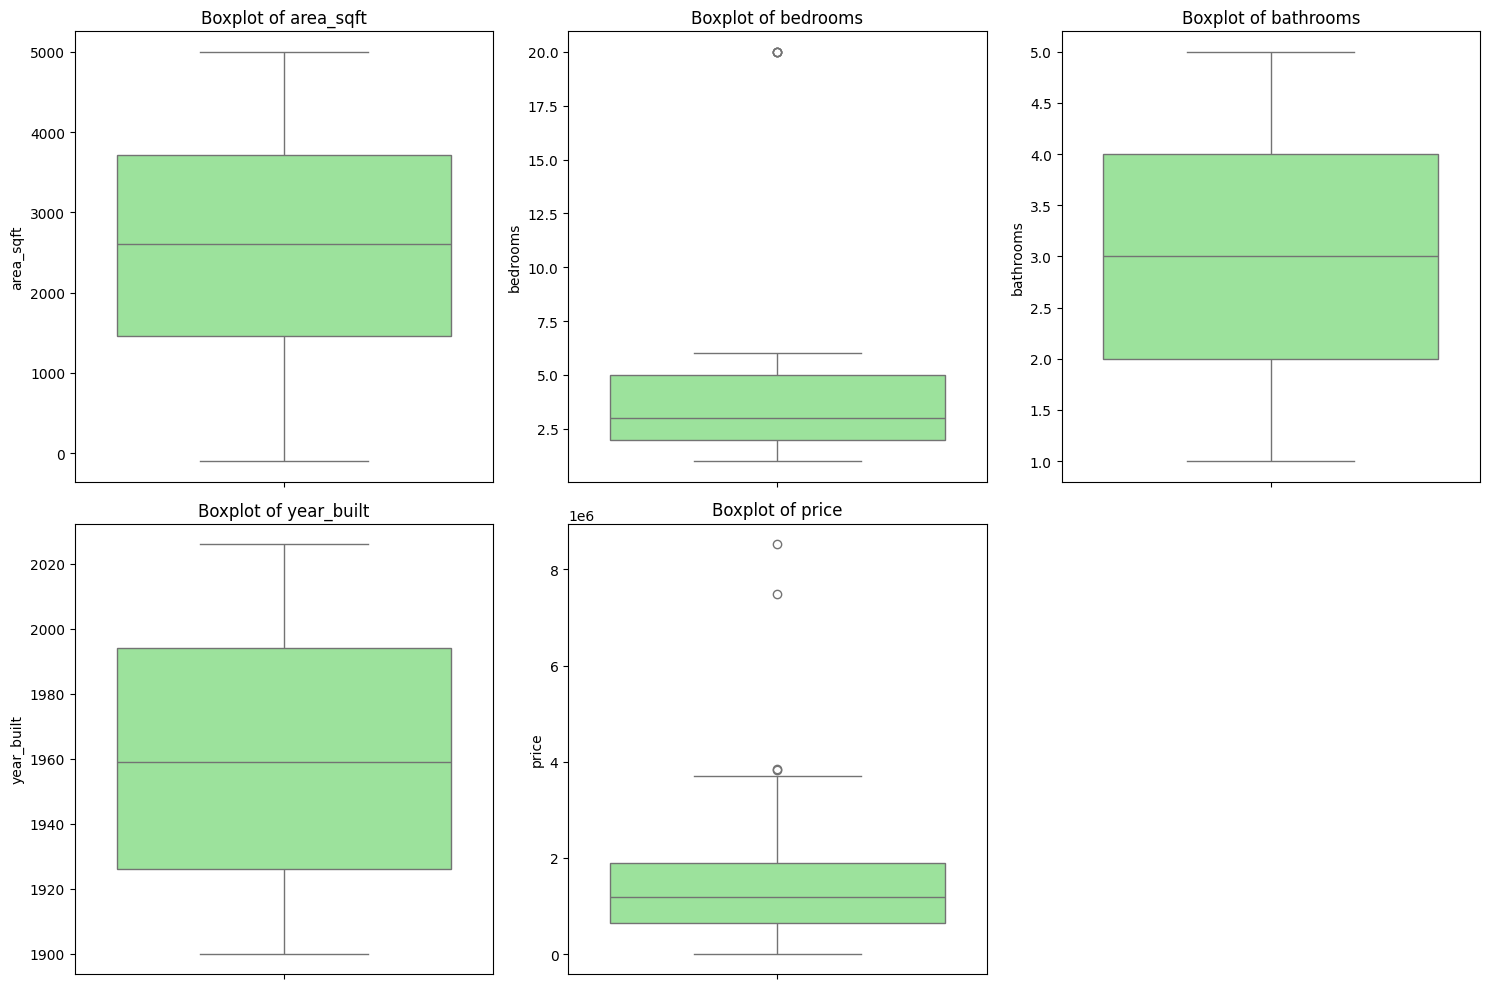

Báo cáo Đánh giá Chất lượng Dữ liệu:


,Chỉ số kiểm tra,Giá trị thực tế
0,Số lượng mẫu (dòng),420
1,Số lượng đặc trưng (cột),7
2,Dữ liệu khuyết thiếu (NaN),164 ô khuyết (bao gồm cả Price NaN và unavaila...
3,Dữ liệu trùng lặp (Duplicates),20 dòng bị trùng
4,Ngoại lệ area_sqft (IQR),0 dòng
5,Ngoại lệ bedrooms (IQR),4 dòng
6,Ngoại lệ bathrooms (IQR),0 dòng
7,Ngoại lệ year_built (IQR),0 dòng
8,Ngoại lệ price (IQR),4 dòng


In [18]:
# Tính toán tỷ lệ phần trăm missing, duplicate và dữ liệu hợp lệ
total_cells = data.size
missing_cells = data.isnull().sum().sum()
duplicate_rows = data.duplicated().sum()

# Vẽ biểu đồ tròn cho dữ liệu khuyết thiếu và trùng lặp
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Biểu đồ 1: Tỷ lệ ô trống trên tổng số ô
axes[0].pie([missing_cells, total_cells - missing_cells],
            labels=['Khuyết (NaN)', 'Hợp lệ'],
            autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
axes[0].set_title('Tỷ lệ Dữ liệu Khuyết (trên tổng số ô)')

# Biểu đồ 2: Tỷ lệ dòng trùng lặp
axes[1].pie([duplicate_rows, len(data) - duplicate_rows],
            labels=['Trùng lặp', 'Không trùng lặp'],
            autopct='%1.1f%%', startangle=90, colors=['#ffcc99','#99ff99'])
axes[1].set_title('Tỷ lệ dòng bị trùng lặp hoàn toàn')

plt.tight_layout()
plt.show()

# Phân bố Boxplot các cột số trên thang đo gốc (không chuẩn hóa)
num_cols = ['area_sqft', 'bedrooms', 'bathrooms', 'year_built', 'price']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel(col)

# Ẩn subplot cuối cùng vì chỉ có 5 đặc trưng số
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

# Báo cáo đánh giá chất lượng dữ liệu
print("Báo cáo Đánh giá Chất lượng Dữ liệu:")
def get_iqr_outliers(col_name):
    col_data = data[col_name].dropna()
    Q1 = col_data.quantile(0.25)
    Q3 = col_data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return len(col_data[(col_data < lower_bound) | (col_data > upper_bound)])

quality_report = pd.DataFrame({
    'Chỉ số kiểm tra': [
        'Số lượng mẫu (dòng)',
        'Số lượng đặc trưng (cột)',
        'Dữ liệu khuyết thiếu (NaN)',
        'Dữ liệu trùng lặp (Duplicates)',
        'Ngoại lệ area_sqft (IQR)',
        'Ngoại lệ bedrooms (IQR)',
        'Ngoại lệ bathrooms (IQR)',
        'Ngoại lệ year_built (IQR)',
        'Ngoại lệ price (IQR)'
    ],
    'Giá trị thực tế': [
        str(len(data)),
        str(len(data.columns)),
        f"{missing_cells} ô khuyết (bao gồm cả Price NaN và unavailable)",
        f"{duplicate_rows} dòng bị trùng",
        f"{get_iqr_outliers('area_sqft')} dòng",
        f"{get_iqr_outliers('bedrooms')} dòng",
        f"{get_iqr_outliers('bathrooms')} dòng",
        f"{get_iqr_outliers('year_built')} dòng",
        f"{get_iqr_outliers('price')} dòng"
    ]
})
display(quality_report)